In [2]:
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and pick your train.csv

import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving train.csv to train.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (891, 12)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate rows: 0


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Missing Age values now:", df['Age'].isnull().sum())

Missing Age values now: 0


**Decision — Age:** Filled missing Age values (177, ~20% of rows) with the median age.
Median was chosen over mean because age distributions often have outliers
(very young infants, elderly passengers), and median is more robust to skew.

In [5]:
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df = df.drop('Cabin', axis=1)
print(df[['Has_Cabin']].value_counts())

Has_Cabin
0            687
1            204
Name: count, dtype: int64


**Decision — Cabin:** 687 missing (77%) — too high to impute reliably.
Instead of guessing values, converted this into a binary `Has_Cabin` flag
(1 = cabin recorded, 0 = missing), preserving useful signal without fabricating data,
then dropped the original Cabin column.


In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing Embarked values now:", df['Embarked'].isnull().sum())

Missing Embarked values now: 0


**Decision — Embarked:** Only 2 missing values — filled with the mode (most common port),
since this has negligible impact on the dataset at this scale.

In [8]:
print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


In [9]:
print("Sex values:", df['Sex'].unique())
print("Embarked values:", df['Embarked'].unique())
print("Pclass values:", df['Pclass'].unique())

Sex values: ['male' 'female']
Embarked values: ['S' 'C' 'Q']
Pclass values: [3 1 2]


In [10]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f"Number of Fare outliers: {len(outliers)}")
print(f"Outlier bounds: below {lower:.2f} or above {upper:.2f}")

Number of Fare outliers: 116
Outlier bounds: below -26.72 or above 65.63


**Standardization check:** Verified Sex, Embarked, and Pclass for inconsistent formatting
(e.g., mismatched casing or spelling). All categorical columns were already clean and
consistent — no standardization was required.

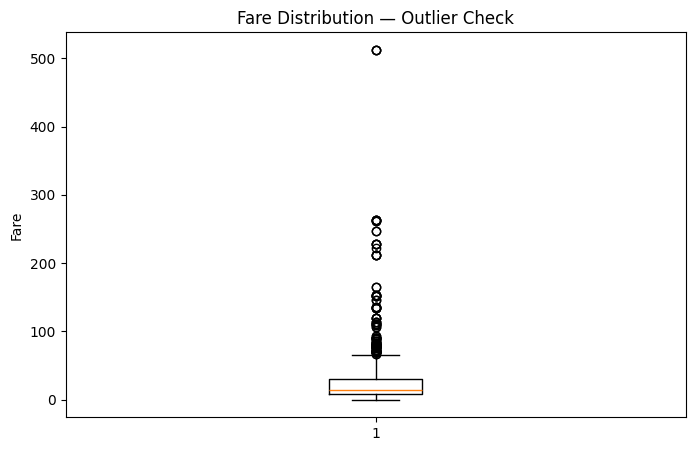

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df['Fare'])
plt.title('Fare Distribution — Outlier Check')
plt.ylabel('Fare')
plt.show()

**Decision — Fare outliers:** Identified 116 outliers (~13%) using the IQR method,
mostly high fares above ₹65.63. These aren't data-entry errors — they reflect genuine
first-class/luxury fares (the Titanic had a wide fare range by class). Decision:
**retained** these values rather than removing or capping them, since they carry real
signal about passenger class and wealth that's relevant to survival analysis.

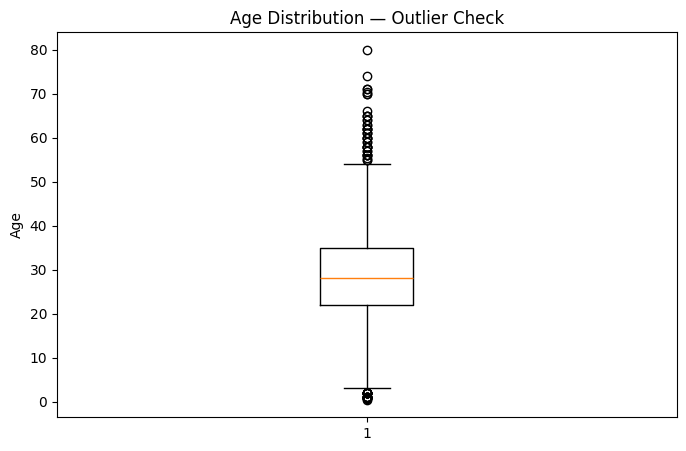

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Age'])
plt.title('Age Distribution — Outlier Check')
plt.ylabel('Age')
plt.show()

**Decision — Age outliers:** Boxplot shows outliers at both extremes — elderly
passengers (up to 80 years) and infants (near age 0). These are legitimate ages,
not data errors, so all values were **retained**. Age extremes are meaningful for
survival analysis (e.g., "women and children first" policies).

In [13]:
df['PassengerId'] = df['PassengerId'].astype(str)
df['Survived'] = df['Survived'].astype(int)
df['Pclass'] = df['Pclass'].astype(int)

print(df.dtypes)

PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Has_Cabin        int64
dtype: object


In [14]:
summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Missing Values', 'Duplicate Rows', 'Columns'],
    'Before Cleaning': [891, 866, 0, 12],
    'After Cleaning': [len(df), df.isnull().sum().sum(), df.duplicated().sum(), len(df.columns)]
})
summary

,Metric,Before Cleaning,After Cleaning
0,Total Rows,891,891
1,Missing Values,866,0
2,Duplicate Rows,0,0
3,Columns,12,12


In [15]:
df.to_csv('titanic_cleaned.csv', index=False)
files.download('titanic_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>